**Import Libraries:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
import joblib
from sklearn.impute import SimpleImputer


In [ ]:
import zipfile

with zipfile.ZipFile("/content/archive (9).zip", "r") as zip_ref:
    zip_ref.extractall("/content/loan_data")

In [ ]:
import os

print(os.listdir("/content/loan_data"))

['test_Y3wMUE5_7gLdaTN.csv', 'train_u6lujuX_CVtuZ9i.csv']


**Load Data:**

In [ ]:
df = pd.read_csv("/content/loan_data/train_u6lujuX_CVtuZ9i.csv")

print(df.head())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [ ]:
df.shape

(614, 13)

**Statistics:**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
# check null vaues
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


**Impute Missing values:**

In [ ]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


/tmp/ipykernel_3583/3178529482.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_3583/3178529482.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [ ]:
df.drop("Loan_ID", axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

print(df.head())


   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Property_Area  Loan_Status  
0              2            1  
1              0            0  
2              2    

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Class imbalance before smote:**

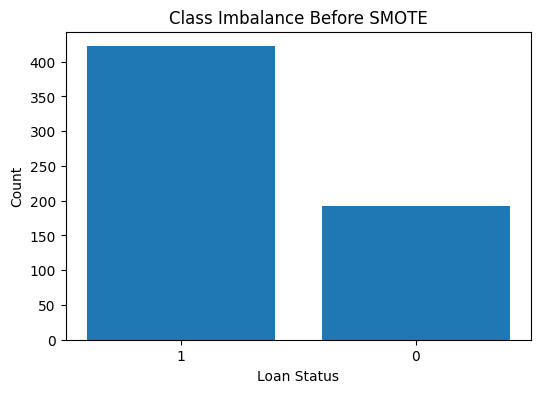

In [ ]:
import matplotlib.pyplot as plt

# class distribution
class_counts = df["Loan_Status"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(class_counts.index.astype(str), class_counts.values)

plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.title("Class Imbalance Before SMOTE")

plt.show()

**Class balance using SMOTE:**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

Loan_Status
1    337
0    337
Name: count, dtype: int64


**Scaling:**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Train models:**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )
}

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

for name, model in models.items():

    print("="*50)
    print("Model:", name)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))

Model: Logistic Regression
Accuracy: 0.8292682926829268
              precision    recall  f1-score   support

           0       0.76      0.66      0.70        38
           1       0.86      0.91      0.88        85

    accuracy                           0.83       123
   macro avg       0.81      0.78      0.79       123
weighted avg       0.83      0.83      0.83       123

Model: Decision Tree
Accuracy: 0.7886178861788617
              precision    recall  f1-score   support

           0       0.66      0.66      0.66        38
           1       0.85      0.85      0.85        85

    accuracy                           0.79       123
   macro avg       0.75      0.75      0.75       123
weighted avg       0.79      0.79      0.79       123

Model: Random Forest
Accuracy: 0.8048780487804879
              precision    recall  f1-score   support

           0       0.71      0.63      0.67        38
           1       0.84      0.88      0.86        85

    accuracy              

In [ ]:
from sklearn.metrics import confusion_matrix

best_model = LogisticRegression(max_iter=5000)

best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred)

print(cm)

[[25 13]
 [ 8 77]]


**Feature Importance:**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

importance = rf.feature_importances_

for i, col in enumerate(X.columns):
    print(col, importance[i])

Gender 0.017908036451165565
Married 0.026762611748565833
Dependents 0.049850881091898544
Education 0.021773754284397137
Self_Employed 0.01885921186514135
ApplicantIncome 0.19451428236704307
CoapplicantIncome 0.10406272814175566
LoanAmount 0.16921610338425985
Loan_Amount_Term 0.05037808437704732
Credit_History 0.29533895413292643
Property_Area 0.05133535215579926


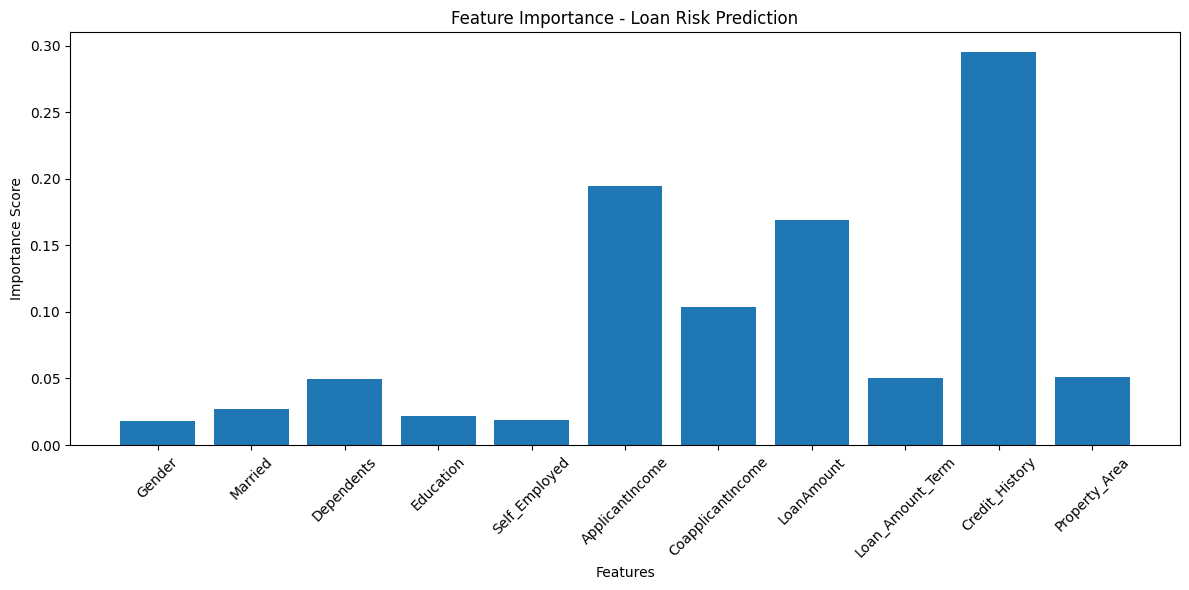

In [ ]:
import matplotlib.pyplot as plt

# feature names
features = X.columns

# importance values from Random Forest
# importance = rf.feature_importances_

plt.figure(figsize=(12,6))
plt.bar(features, importance)

plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance - Loan Risk Prediction")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Save model:**

In [ ]:
import joblib

joblib.dump(best_model, "loan_risk_model.pkl")

['loan_risk_model.pkl']

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
import os
print(os.listdir())

['.config', 'loan_risk_model.pkl', 'archive (9).zip', 'loan_data', 'scaler.pkl', 'sample_data']


**Load model:**

In [ ]:
model = joblib.load("loan_risk_model.pkl")
scaler = joblib.load("scaler.pkl")

**Predict model:**

In [ ]:
# example applicant

new_data = np.array([[
    1,      # Gender (Male)
    1,      # Married
    0,      # Dependents
    0,      # Education
    0,      # Self_Employed
    5000,   # ApplicantIncome
    2000,   # CoapplicantIncome
    150,    # LoanAmount
    360,    # Loan_Amount_Term
    1,      # Credit_History
    2       # Property_Area
]])

In [ ]:
new_data = scaler.transform(new_data)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
prediction = model.predict(new_data)

print(prediction)

[1]
